# Data Exploration

## Authors: Gribaldo Edoardo Silvio, Tichy, Vojtech

In [945]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [946]:
X_train = pd.read_csv('vehicles/vehicles-train.csv', low_memory=False)
X_test = pd.read_csv('vehicles/vehicles-test.csv', low_memory=False)

y_train = X_train['fuelCost08']
y_test = X_test['fuelCost08']

X_train.drop(columns=['fuelCost08'], inplace=True)
X_test.drop(columns=['fuelCost08'], inplace=True)

In [947]:
print(X_train.columns)

Index(['barrels08', 'barrelsA08', 'charge120', 'charge240', 'city08',
       'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2',
       'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08', 'comb08U',
       'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders',
       'displ', 'drive', 'engId', 'eng_dscr', 'feScore', 'fuelCostA08',
       'fuelType', 'fuelType1', 'ghgScore', 'ghgScoreA', 'highway08',
       'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD', 'highwayE',
       'highwayUF', 'hlv', 'hpv', 'id', 'lv2', 'lv4', 'make', 'model',
       'mpgData', 'phevBlended', 'pv2', 'pv4', 'range', 'rangeCity',
       'rangeCityA', 'rangeHwy', 'rangeHwyA', 'trany', 'UCity', 'UCityA',
       'UHighway', 'UHighwayA', 'VClass', 'year', 'youSaveSpend', 'guzzler',
       'trans_dscr', 'tCharger', 'sCharger', 'atvType', 'fuelType2', 'rangeA',
       'evMotor', 'mfrCode', 'c240Dscr', 'charge240b', 'c240bDscr',
       'createdOn', 'modifiedOn', 'startStop'

### Handling columns irrelevant to the task

In [948]:
# Drop columns related to ids

X_train.drop(columns=['id', 'engId', 'createdOn', 'modifiedOn', 'mfrCode'], inplace=True)
X_test.drop(columns=['id', 'engId', 'createdOn', 'modifiedOn', 'mfrCode'], inplace=True)

In [949]:
#columns_to_drop = ['trans_dscr', 'c240Dscr']
columns_to_drop = ['c240Dscr']

X_train.drop(columns=columns_to_drop, inplace=True)
X_test.drop(columns=columns_to_drop, inplace=True)

### Column Analysis for duplicity

In [950]:
# Drop these columns because they are combined into comb08

X_train.drop(columns=['highway08', 'city08'], inplace=True)
X_test.drop(columns=['highway08', 'city08'], inplace=True)

In [951]:
X_train.drop(columns=['UCity', 'UHighway', 'comb08U', 'c240bDscr'], inplace=True)
X_test.drop(columns=['UCity', 'UHighway', 'comb08U', 'c240bDscr'], inplace=True)

In [952]:
X_train['passenger_volume'] = X_train['hpv'] + X_train['pv2'] + X_train['pv4']

X_train['luggage_volume'] = X_train['hlv'] + X_train['lv2'] + X_train['lv4']

X_train['total_interior_volume'] = X_train['passenger_volume'] + X_train['luggage_volume']

volume_cols_to_drop = ['hpv', 'pv2', 'pv4', 'hlv', 'lv2', 'lv4', 'passenger_volume', 'luggage_volume']

X_train.drop(columns=volume_cols_to_drop, inplace=True)

In [953]:
# delete all the columns which have 1 single value in the whole column

X_train = X_train.loc[:, X_train.nunique() > 1]

In [954]:
X_train.describe()

,barrels08,barrelsA08,charge240,city08U,cityA08,cityA08U,cityCD,cityE,cityUF,co2,co2A,co2TailpipeAGpm,co2TailpipeGpm,comb08,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,feScore,fuelCostA08,ghgScore,ghgScoreA,highway08U,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,UCityA,UHighwayA,year,youSaveSpend,charge240b,phevCity,phevHwy,phevComb,total_interior_volume
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,29891.000000,29894.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,17.366349,0.263933,0.025012,4.467117,0.616500,0.372864,0.000491,0.202184,0.000760,66.066133,6.385333,21.794245,469.097339,20.333233,0.690733,0.410354,0.209325,0.000409,0.000742,5.783145,3.336559,0.047100,98.666667,0.044433,-0.918500,6.020943,0.819133,0.480626,0.000292,0.218730,0.000720,0.414967,0.362864,0.040175,0.351890,0.036279,0.770003,1.111066,2002.029433,-2533.925000,0.004458,0.075100,0.073233,0.074033,66.640600
std,4.467786,1.259287,0.436744,10.000516,4.073481,3.723304,0.044698,3.042655,0.020367,158.137096,60.071990,104.032037,118.978895,6.701608,4.221234,3.775767,3.133487,0.039586,0.019905,1.755709,1.340839,2.477072,469.912314,2.470573,0.676515,12.384378,4.606488,4.019322,0.033203,3.266577,0.019383,8.307338,8.056707,1.227417,8.160266,1.090742,5.600373,6.473490,9.839959,2428.603395,0.144984,2.064672,1.951716,2.003552,68.680013
min,0.059892,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1984.000000,-21250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.327048,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,386.391304,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.200000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1995.000000,-3750.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,16.480500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,452.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,3.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2004.000000,-2500.000000,0.000000,0.000000,0.000000,0.000000,86.000000
75%,19.381068,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,532.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.300000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2010.000000,-750.000000,0.000000,0.000000,0.000000,0.000000,113.000000
max,47.068308,18.304342,12.000000,138.304000,127.000000,127.093000,5.350000,122.000000,0.849000,847.000000,719.000000,719.000000,1269.571429,124.000000,117.000000,116.936400,121.000000,4.800000,0.834000,16.000000,8.400000,10.000000,3900.000000,10.000000,8.000000,111.370000,107.000000,106.531000,4.060000,120.000000,0.813000,294.000000,285.700000,77.504000,303.200000,65.632000,181.560900,152.187800,2017.000000,3750.000000,7.000000,

In [955]:
is_auto = X_train['trany'].str.contains('auto', case=False, na=False)
is_manual = X_train['trany'].str.contains('manual', case=False, na=False)

X_train['automatic'] = np.select((is_auto, is_manual), [True,False], default=np.nan)
X_train['automatic'] = X_train['automatic'].astype(bool)

In [956]:
# TODO: What to do with these missing values?
X_train[X_train['automatic'].isna()]

,barrels08,barrelsA08,charge240,city08U,cityA08,cityA08U,cityCD,cityE,cityUF,co2,co2A,co2TailpipeAGpm,co2TailpipeGpm,comb08,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,drive,eng_dscr,feScore,fuelCostA08,fuelType,fuelType1,ghgScore,ghgScoreA,highway08U,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,make,model,mpgData,phevBlended,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,trany,UCityA,UHighwayA,VClass,year,youSaveSpend,guzzler,trans_dscr,atvType,fuelType2,rangeA,evMotor,charge240b,startStop,phevCity,phevHwy,phevComb,total_interior_volume,automatic


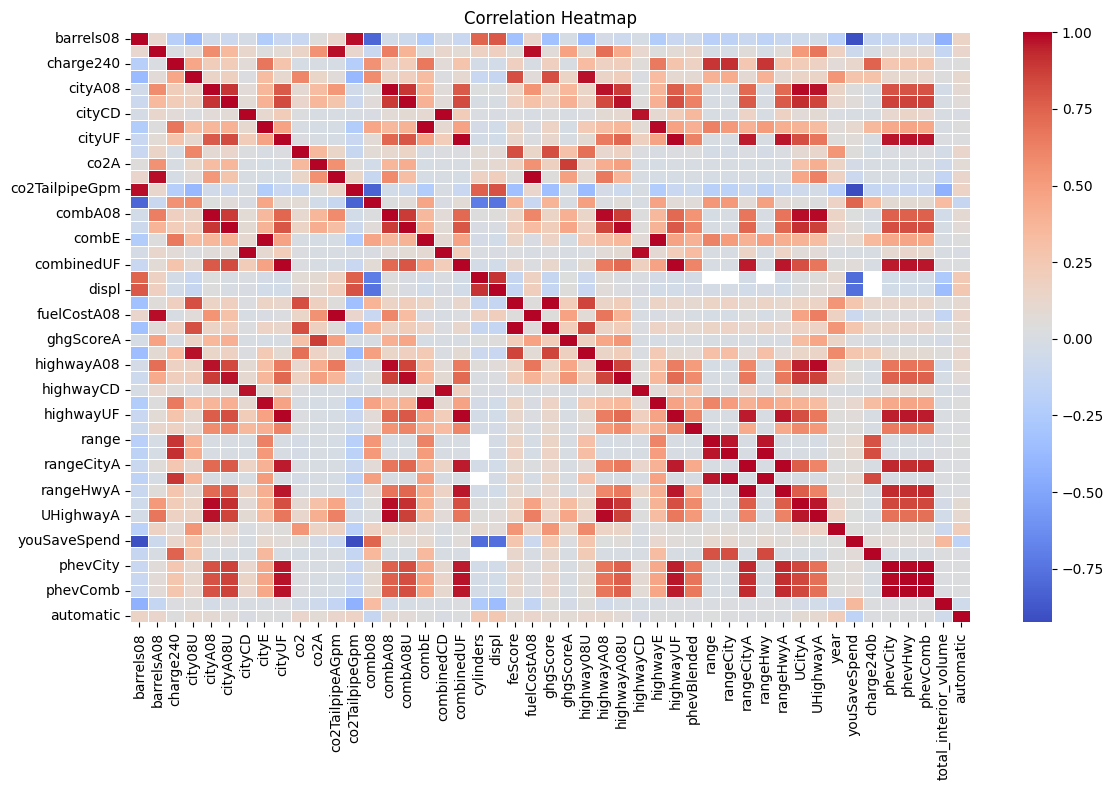

In [957]:
plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(numeric_only=True), cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [958]:
# Calculate average CO2 emissions per make, sorted highest to lowest
X_train.groupby("make")["co2"].mean().sort_values(ascending=False)

make
Pagani                                671.000000
SRT                                   607.000000
Mobility Ventures LLC                 547.500000
Ram                                   470.705882
McLaren Automotive                    445.727273
Bugatti                               317.000000
Fiat                                  241.263158
MINI                                  178.130000
Ferrari                               174.694611
Fisker                                169.000000
Bentley                               165.888889
Roush Performance                     157.176471
Land Rover                            155.592593
Maserati                              147.705128
Aston Martin                          145.584000
Lamborghini                           137.806452
Infiniti                              136.110390
Lincoln                               134.106557
Jaguar                                126.684385
Rolls-Royce                           126.474074
Scion          

In [959]:
def handleFuelType(df: pd.DataFrame) -> pd.DataFrame:
    """
    @brief simplifies 'fuelType' attribute by reducing the overall number of values the attribute can have
           adds a new column 'premium' which says, whether premium fuel was used or not
           fills all missing values in 'startStop' column as False

           initially the 'fuelType' can have all of these values:

                Regular
                Premium
                Gasoline or E85
                Diesel
                Premium or E85
                Electricity
                Midgrade
                CNG
                Gasoline or natural gas
                Premium Gas or Electricity
                Premium and Electricity
                Regular Gas and Electricity
                Gasoline or propane
                Regular Gas or Electricity

           this function reduces the possible values to:

                Gas
                Diesel
                Hybrid
                Electric
                CNG
                FFV

           plus introduces 'premium' boolean column.

    @param df input dataframe
    @return transformed dataframe        
    """
    df['premium'] = df['fuelType'].isin(["Premium","Premium or E85","Premium Gas or Electricity","Premium and Electricity"])
    df['premium'] = df['premium'].astype('category')

    reduced_gas_types = {
        'Regular' : 'Gas',
        'Premium' : 'Gas',
        'Gasoline or E85' : 'Gas',
        'Premium or E85' : 'Gas',
        'Midgrade' : 'Gas',
        'Gasoline or natural gas' : 'Bifuel',
        'Gasoline or propane' : 'Bifuel',
        'Premium Gas or Electricity' : 'Hybrid',
        'Regular Gas and Electricity' : 'Hybrid',
        'Regular Gas or Electricity' : 'Hybrid',
        'Premium and Electricity' : 'Hybrid'
    }
    df['fuelType'] = df['fuelType'].replace(reduced_gas_types)
    df.loc[df['atvType'] == 'FFV', 'fuelType'] = 'FFV'

    df['startStop'].fillna(False)

    return df

X_train = handleFuelType(X_train)

gas_cars = X_train[X_train['fuelType'] == 'Gas'].copy()
ffv_cars = X_train[X_train['fuelType'] == 'FFV'].copy()
diesel_cars = X_train[X_train['fuelType1'] == 'Diesel'].copy()
hybrid_cars = X_train[X_train['fuelType'] == 'Hybrid'].copy()
ev_cars = X_train[X_train['fuelType1'] == 'Electricity'].copy()
bi_cars = X_train[X_train['fuelType'] == 'Bifuel'].copy()

cars_types = [gas_cars, ffv_cars, diesel_cars, hybrid_cars, ev_cars]

In [960]:
gas_cars = gas_cars.loc[:, gas_cars.nunique() > 1]
ffv_cars = ffv_cars.loc[:, ffv_cars.nunique() > 1]
diesel_cars = diesel_cars.loc[:, diesel_cars.nunique() > 1]
hybrid_cars = hybrid_cars.loc[:, hybrid_cars.nunique() > 1]
ev_cars = ev_cars.loc[:, ev_cars.nunique() > 1]
bi_cars = bi_cars.loc[:, bi_cars.nunique() > 1]

In [961]:
cars_types = [gas_cars, ffv_cars, diesel_cars, hybrid_cars, ev_cars, bi_cars]
cars_names = ['Gas', 'FFV', 'Diesel', 'Hybrid', 'EV', 'Bifuel']

# Print the column counts
for name, car_df in zip(cars_names, cars_types):
    print(f"{name} cars: {len(car_df.columns)} columns")

Gas cars: 29 columns
FFV cars: 39 columns
Diesel cars: 24 columns
Hybrid cars: 50 columns
EV cars: 25 columns
Bifuel cars: 37 columns


## Gas Cars

In [962]:
gas_cars.head(20)

,barrels08,city08U,co2,co2A,co2TailpipeGpm,comb08,cylinders,displ,drive,eng_dscr,feScore,fuelType1,ghgScore,ghgScoreA,highway08U,make,model,mpgData,trany,VClass,year,youSaveSpend,guzzler,trans_dscr,evMotor,startStop,total_interior_volume,automatic,premium
0,15.689436,0.0,-1,-1,423.190476,21,4.0,2.0,Rear-Wheel Drive,(FFS),-1,Regular Gasoline,-1,-1,0.0,Alfa Romeo,Spider Veloce 2000,Y,Manual 5-spd,Two Seaters,1985,-1250,NaN,NaN,NaN,NaN,0,False,False
1,29.950562,0.0,-1,-1,807.909091,11,12.0,4.9,Rear-Wheel Drive,(GUZZLER),-1,Regular Gasoline,-1,-1,0.0,Ferrari,Testarossa,N,Manual 5-spd,Two Seaters,1985,-8000,T,NaN,NaN,NaN,0,False,False
2,12.195570,0.0,-1,-1,329.148148,27,4.0,2.2,Front-Wheel Drive,(FFS),-1,Regular Gasoline,-1,-1,0.0,Dodge,Charger,Y,Manual 5-spd,Subcompact Cars,1985,500,NaN,SIL,NaN,NaN,96,False,False
3,29.950562,0.0,-1,-1,807.909091,11,8.0,5.2,Rear-Wheel Drive,NaN,-1,Regular Gasoline,-1,-1,0.0,Dodge,B150/B250 Wagon 2WD,N,Automatic 3-spd,Vans,1985,-8000,NaN,NaN,NaN,NaN,0,True,False
4,17.337486,0.0,-1,-1,467.736842,19,4.0,2.2,4-Wheel or All-Wheel Drive,"(FFS,TRBO)",-1,Premium Gasoline,-1,-1,0.0,Subaru,Legacy AWD Turbo,N,Manual 5-spd,Compact Cars,1993,-3750,NaN,NaN,NaN,NaN,104,False,True
5,14.964294,0.0,-1,-1,403.954545,22,4.0,1.8,Front-Wheel Drive,(FFS),-1,Regular Gasoline,-1,-1,0.0,Subaru,Loyale,N,Automatic 3-spd,Compact Cars,1993,-750,NaN,NaN,NaN,NaN,103,True,False
6,13.184400,0.0,-1,-1,355.480000,25,4.0,1.8,Front-Wheel Drive,(FFS),-1,Regular Gasoline,-1,-1,0.0,Subaru,Loyale,Y,Manual 5-spd,Compact Cars,1993,0,NaN,NaN,NaN,NaN,103,False,False
7,13.733750,0.0,-1,-1,370.291667,24,4.0,1.6,Front-Wheel Drive,(FFS),-1,Regular Gasoline,-1,-1,0.0,Toyota,Corolla,Y,Automatic 3-spd,Compact Cars,1993,-250,NaN,NaN,NaN,NaN,102,True,False
8,12.657024,0.0,-1,-1,341.807692,26,4.0,1.6,Front-Wheel Drive,(FFS),-1,Regular Gasoline,-1,-1,0.0,Toyota,Corolla,Y,Manual 5-spd,Compact Cars,1993,250,NaN,NaN,NaN,NaN,102,False,False
9,13.184400,0.0,-1,-1,355.480000,25,4.0,1.8,Front-Wheel Drive,(FFS),-1,Regular Gasoline,-1,-1,0.0,Toyota,Corolla,Y,Automatic 4-spd,Compact Cars,1993,0,NaN,NaN,NaN,NaN,102,True,False


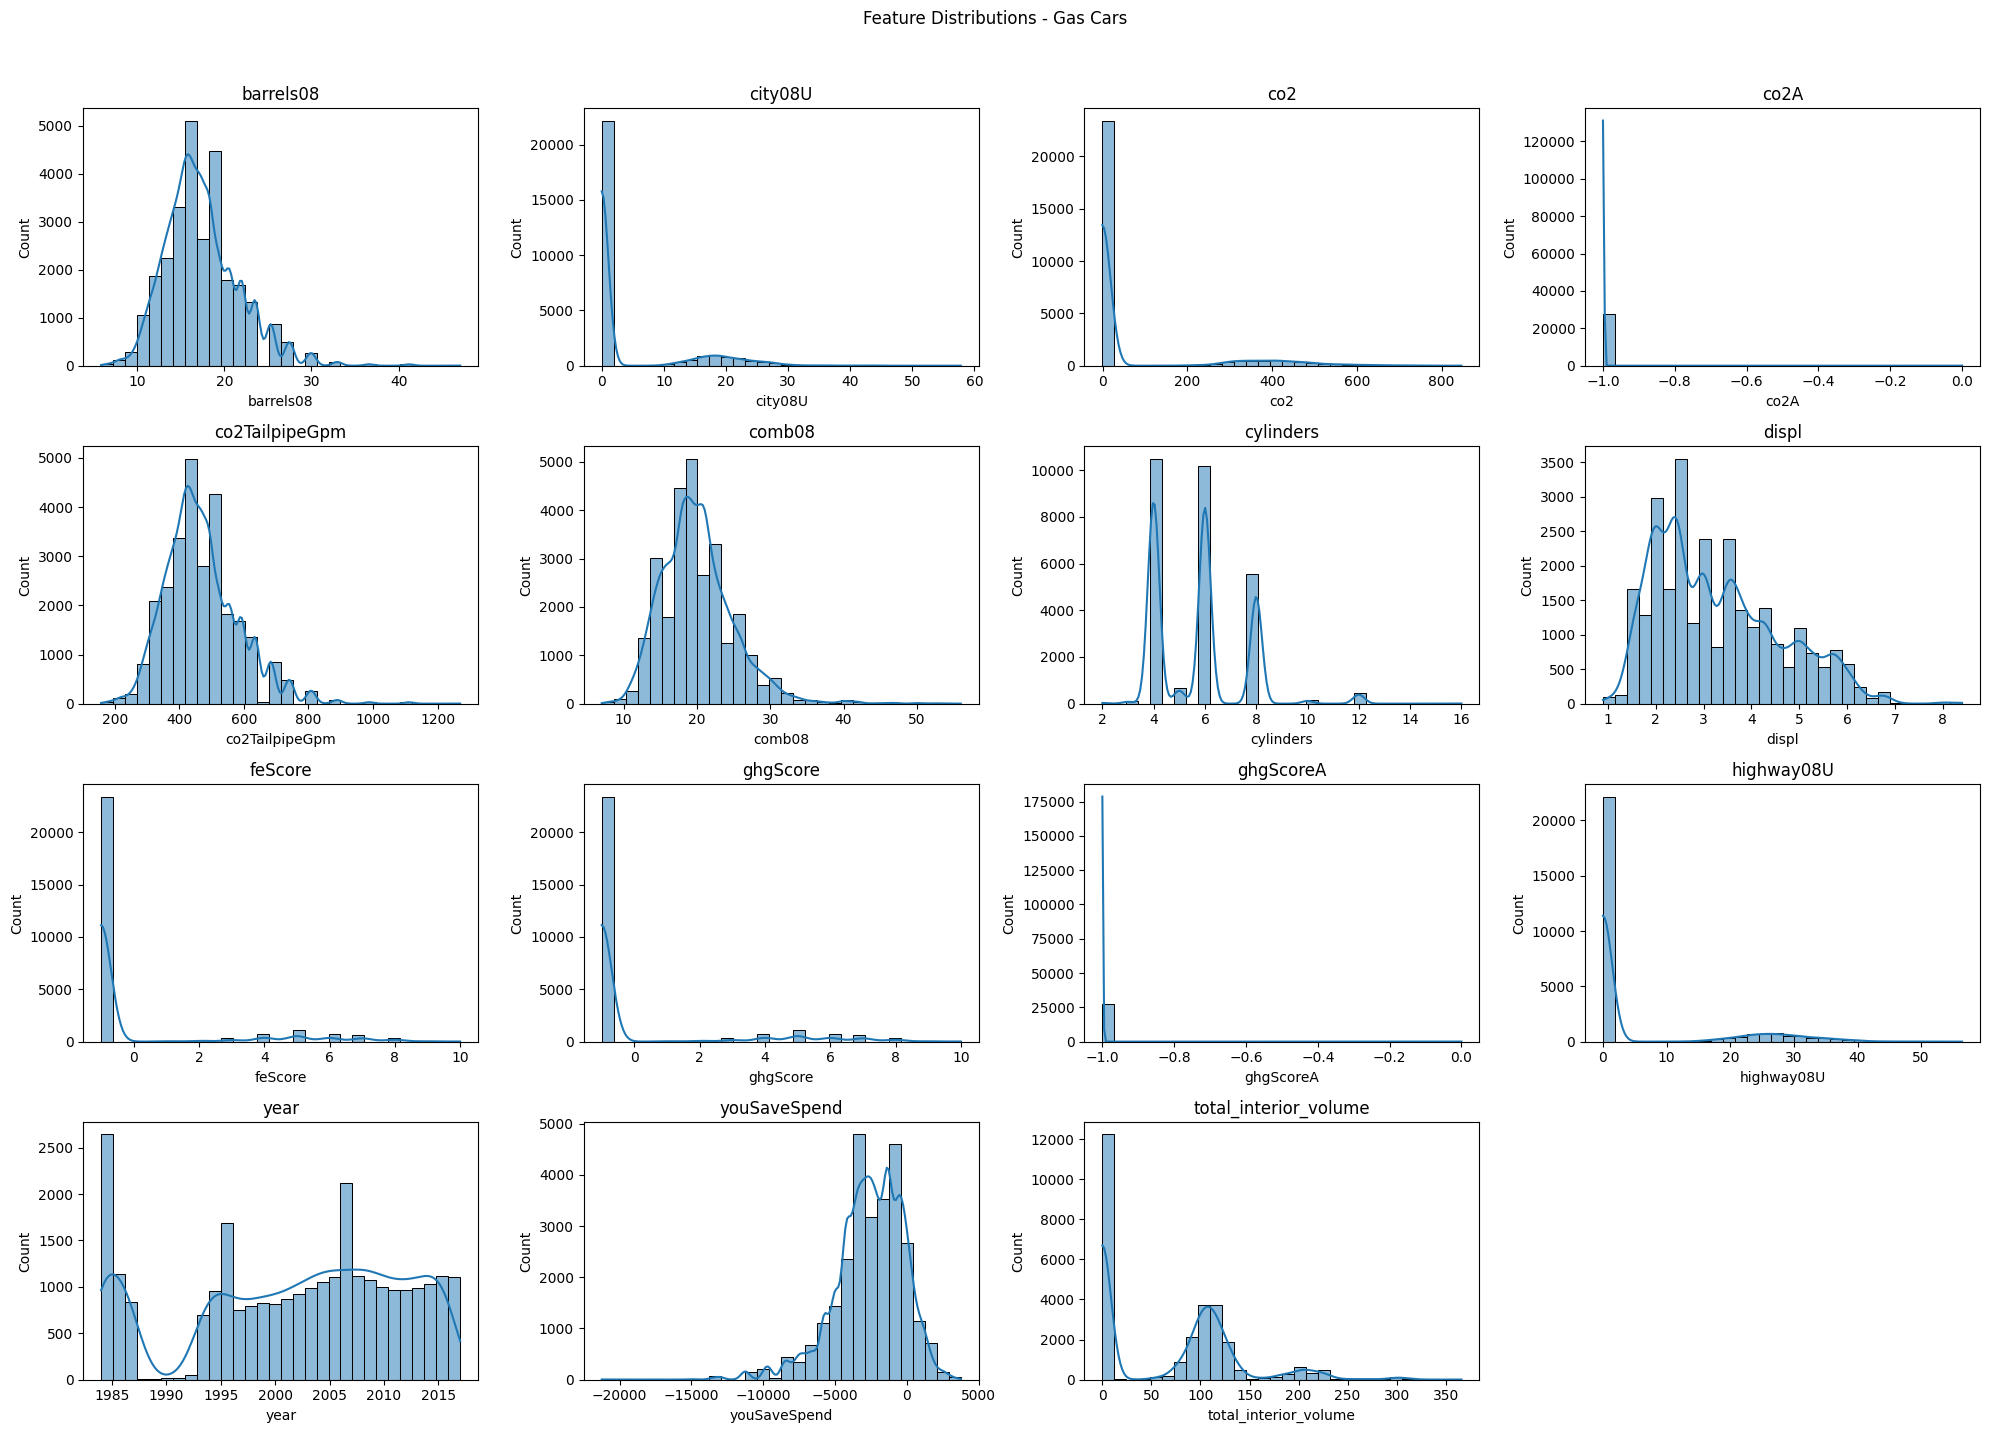

In [963]:
def plot_distribution(df, name):
    
    numeric_cols = df.select_dtypes(include=np.number).columns


    if df.empty or len(numeric_cols) == 0:
        print(f"No numeric features to plot for '{name}' (empty dataset or no numeric columns).")
    else:
        n = len(numeric_cols)
        ncols = 4
        nrows = int(np.ceil(n / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(numeric_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
            axes[i].set_title(col)

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f"Feature Distributions - {name}", y=1.02)
        plt.tight_layout()
        plt.show()
        
plot_distribution(gas_cars, "Gas Cars")

In [964]:
print(len(gas_cars.loc[gas_cars['ghgScore'] != gas_cars['feScore']]))

gas_cars.drop(columns=['ghgScore', 'city08U', 'co2', 'highway08U'], inplace=True)

0


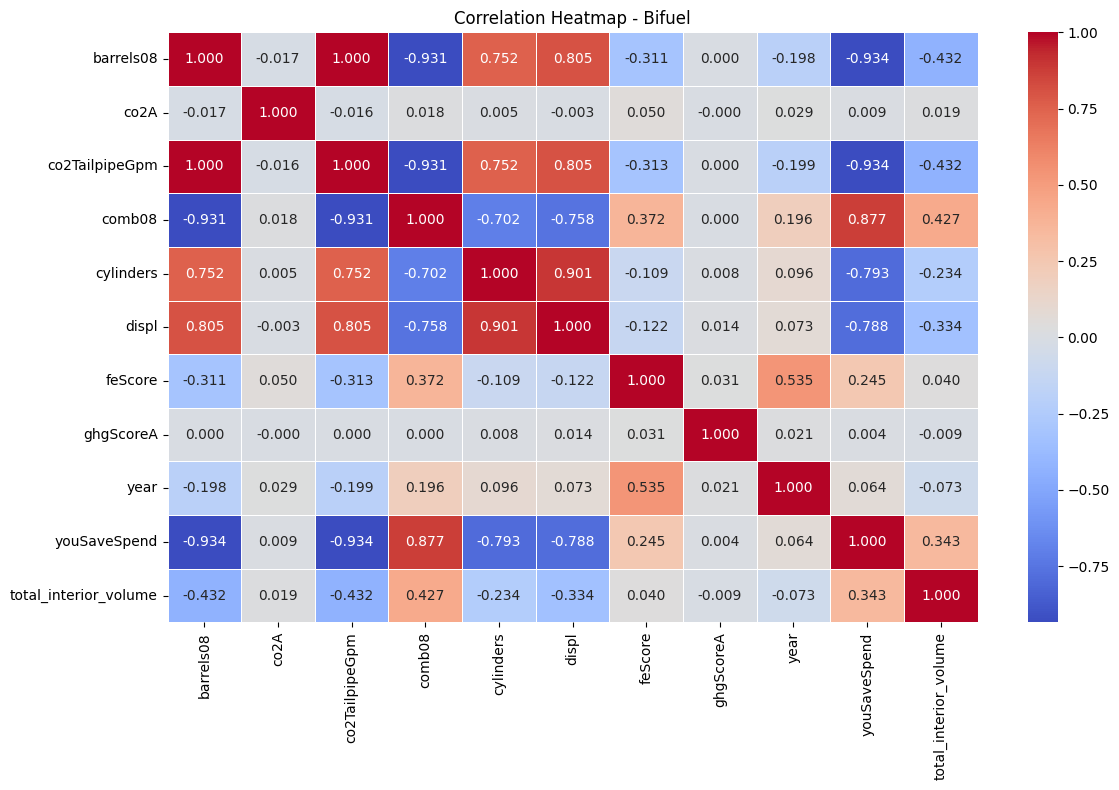

In [965]:
numeric_cols = gas_cars.select_dtypes(include=np.number).columns

if gas_cars.empty or len(numeric_cols) < 2:
    print(f"Cannot plot correlation heatmap for '{name}': not enough numeric data.")
else:
    corr = gas_cars[numeric_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap='coolwarm', linewidths=0.5, fmt='.3f', annot=True)
    plt.title(f"Correlation Heatmap - {name}")
    plt.tight_layout()
    plt.show()

In [966]:
# Drop columns with very high pairwise correlation (|corr| >= 0.99)
corr_matrix = gas_cars[numeric_cols].corr().abs()

# Keep only upper triangle of correlation matrix (without diagonal)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columns to drop
high_corr_cols = [col for col in upper.columns if (upper[col] >= 0.95).any()]

print(f"Columns to drop ({len(high_corr_cols)}): {high_corr_cols}")

# Drop from gas_cars
gas_cars.drop(columns=high_corr_cols, inplace=True)

# Refresh numeric_cols after dropping
numeric_cols = gas_cars.select_dtypes(include=np.number).columns
print(f"Remaining numeric columns: {len(numeric_cols)}")

Columns to drop (1): ['co2TailpipeGpm']
Remaining numeric columns: 10


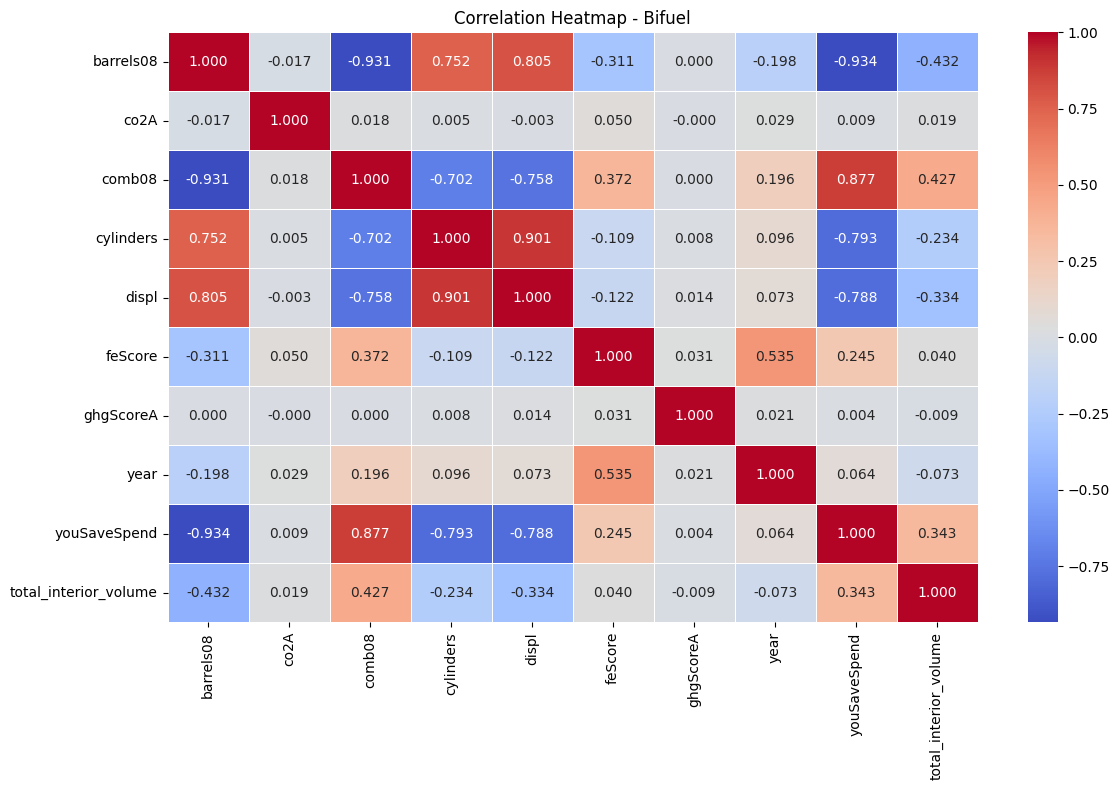

In [967]:

if gas_cars.empty or len(numeric_cols) < 2:
    print(f"Cannot plot correlation heatmap for '{name}': not enough numeric data.")
else:
    corr = gas_cars[numeric_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap='coolwarm', linewidths=0.5, fmt='.3f', annot=True)
    plt.title(f"Correlation Heatmap - {name}")
    plt.tight_layout()
    plt.show()

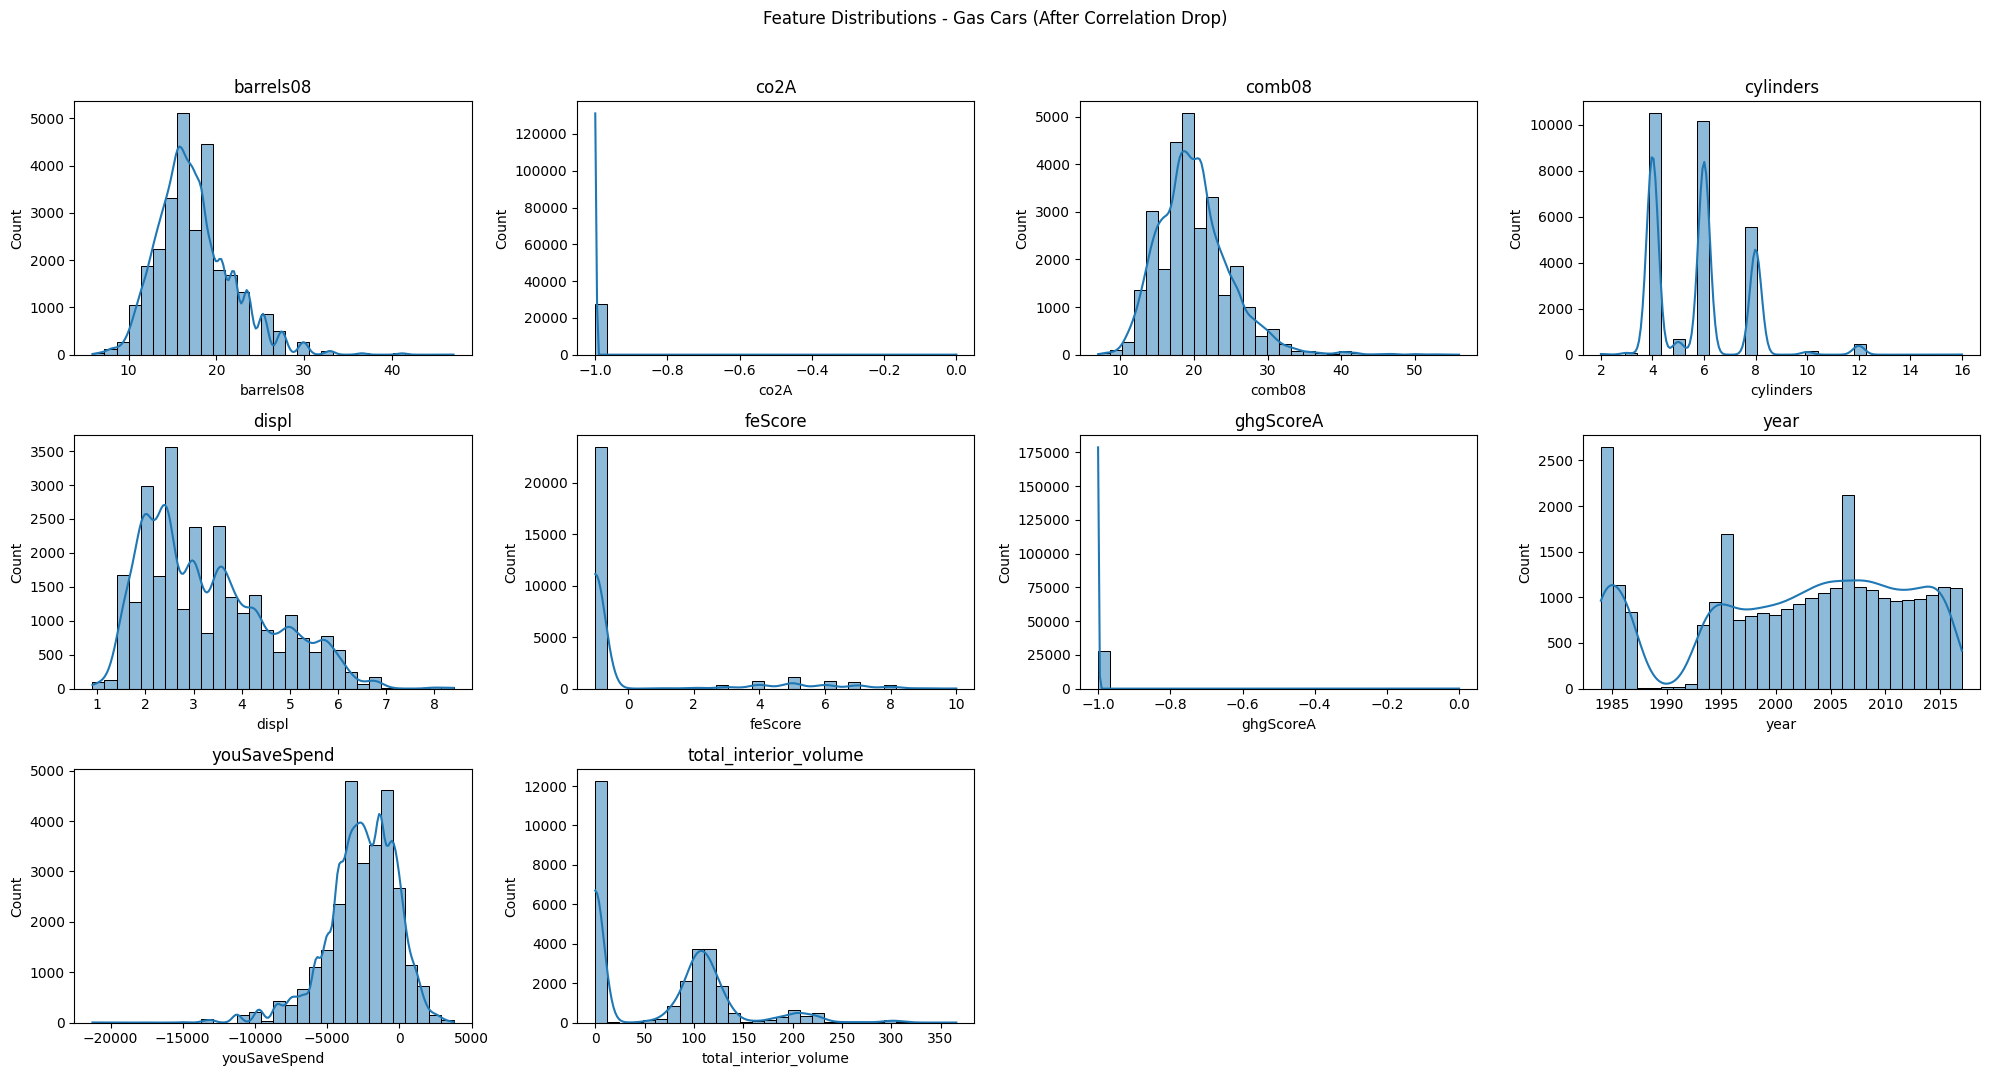

In [968]:
plot_distribution(gas_cars, "Gas Cars (After Correlation Drop)")

In [969]:
gas_cars.select_dtypes(include=['object', 'category', 'str']).describe()

,drive,eng_dscr,fuelType1,make,model,mpgData,trany,VClass,guzzler,trans_dscr,evMotor,startStop,premium
count,26633,13282,27657,27657,27657,27657,27655,27657,1851,11443,360,4510,27657
unique,7,396,3,110,3020,2,43,33,3,48,24,2,2
top,Front-Wheel Drive,(FFS),Regular Gasoline,Chevrolet,Mustang,N,Automatic 4-spd,Compact Cars,G,CLKUP,288V Ni-MH,N,False
freq,9755,4469,18917,2347,154,18390,7774,4144,1221,5996,113,3291,18981


In [970]:
gas_cars['trany'].value_counts()


trany
Automatic 4-spd                     7774
Manual 5-spd                        5606
Automatic (S6)                      2312
Manual 6-spd                        2278
Automatic 5-spd                     2007
Automatic 3-spd                     1781
Automatic 6-spd                      935
Automatic (S5)                       811
Manual 4-spd                         800
Automatic (S8)                       670
Automatic (variable gear ratios)     608
Automatic 7-spd                      547
Automatic (S7)                       230
Automatic (S4)                       225
Auto(AM-S7)                          206
Automatic 8-spd                      152
Auto(AV-S6)                          135
Auto(AM7)                            119
Auto(AM6)                             94
Auto(AM-S6)                           58
Manual 7-spd                          56
Manual 3-spd                          55
Auto(AV-S7)                           54
Automatic 9-spd                       41
Auto(AV-S8

In [971]:
def handle_transmission(df: pd.DataFrame) -> pd.DataFrame:
    """
    @brief Handles the transmission attribute. This column is split into three:
        1. bool column whether the transmission is automatic of manual
        2. number of gears (CVTs are handled differently)
            The number is extracted from the value, except from CVTs which have variable gear ratio, these will be handled later.
        3. type of the transmission (TBD)
            The transmission type is derived from the value of the attribute.

    @param df input dataframe
    @return transformed dataframe
    """

	# manual / automatic
    is_auto = df['trany'].str.contains('auto', case=False, na=False)
    is_manual = df['trany'].str.contains('manual', case=False, na=False)

    df['automatic'] = np.select((is_auto, is_manual), [1,0], default=np.nan)    
    df['automatic'] = df['automatic'].astype(bool)

    # Number of gears
    df['numOfGears'] = df['trany'].str.extract(r'(\d)')

    # type of transmission
    df['isCvt'] = df['trany'].str.contains(r'(AV)|(variable gear ratios)', case=False, regex=False)
    return df

gas_cars = handle_transmission(gas_cars)
gas_cars['numOfGears'].value_counts(dropna=False)

numOfGears
4      8818
5      8439
6      5826
3      1838
7      1214
8       851
NaN     614
9        57
Name: count, dtype: int64

In [972]:
# TODO: what to do with transmission descriptions?
gas_cars['trans_dscr'].value_counts(dropna=False)

trans_dscr
NaN                16214
CLKUP               5996
SIL                 1367
2MODE CLKUP         1128
EMS 2MODE CLKUP      491
3MODE CLKUP          489
2MODE                325
2MODE 2LKUP          263
EMS                  227
Creeper              186
3MODE                155
CMODE CLKUP          130
CMODE                130
VMODE CLKUP          105
EMS CLKUP             50
DC/FW                 46
EMS 2MODE             43
VLKUP                 41
6MODE CLKUP           41
4MODE                 32
2LKUP                 31
VMODE VLKUP           26
SIL Creeper           24
2MODE DC/FW           19
CMODE VLKUP           17
EMS 3MODE             10
SIL EMS                7
3LKUP                  6
6MODE                  6
4MODE CLKUP            6
SIL 3MODE              6
Overdrive              5
SIL 2MODE CLKUP        5
Lockup                 4
2MODE VLKUP            3
EMS 3MODE CLKUP        3
2MODE CLKUP FW         2
3MODE 2LKUP            2
EMS CMODE CLKUP        2
VMODE         

### What to do with the other (categorical) columns?
- drive	-> keep
- eng_dscr	-> not sure whether its worth keeping
- fuelType1	-> we already grouped the cars based on fuelType would personally discard this
- make	-> maybe model is more relevant, probably discard
- model	-> maybe useful
- mpgData -> lots of missing data N
- trany	-> very useful attribute
- VClass -> also interesting attribute, but the number of values needs to be reduced	
- guzzler -> i would discard this
- trans_dscr -> not sure whether it can be useful, needs analysis 	
- evMotor -> how this column got into dataframe with gasoline cars? xd 	
- startStop	-> useful, not much data though
- premium -> also useful

### Reduce the number of values

here we have rear/front wheel drive and all wheel drive. We could convert 4 wheel drive to all wheel drive since its basically the same. But what about 2 wheel drives? how do we know whether the cars is Front or Rear? 

In [973]:
gas_cars['drive'].value_counts(dropna=False)

drive
Front-Wheel Drive             9755
Rear-Wheel Drive              9080
4-Wheel or All-Wheel Drive    4895
All-Wheel Drive               1588
NaN                           1024
4-Wheel Drive                  789
2-Wheel Drive                  421
Part-time 4-Wheel Drive        105
Name: count, dtype: int64

In [974]:
drive_mapping = {
    '4-Wheel or All-Wheel Drive' : 'All-Wheel Drive',
    '4-Wheel Drive' : 'All-Wheel Drive'
}

gas_cars['drive'].replace(drive_mapping)

0               Rear-Wheel Drive
1               Rear-Wheel Drive
2              Front-Wheel Drive
3               Rear-Wheel Drive
4                All-Wheel Drive
5              Front-Wheel Drive
6              Front-Wheel Drive
7              Front-Wheel Drive
8              Front-Wheel Drive
9              Front-Wheel Drive
10             Front-Wheel Drive
11             Front-Wheel Drive
12             Front-Wheel Drive
13             Front-Wheel Drive
14              Rear-Wheel Drive
15             Front-Wheel Drive
16              Rear-Wheel Drive
17              Rear-Wheel Drive
18             Front-Wheel Drive
19             Front-Wheel Drive
20              Rear-Wheel Drive
21              Rear-Wheel Drive
22              Rear-Wheel Drive
23             Front-Wheel Drive
24             Front-Wheel Drive
25              Rear-Wheel Drive
26             Front-Wheel Drive
27             Front-Wheel Drive
28             Front-Wheel Drive
29             Front-Wheel Drive
30        

In [ ]:
pd.set_option('display.max_columns', None)

print(gas_cars[(gas_cars['drive'] == '2-Wheel Drive')].VClass.value_counts())

       year       make                 model                       VClass
21110  1999       Ford       F150 Pickup 2WD   Standard Pickup Trucks 2WD
21112  1999  Chevrolet        Tahoe 1500 2WD  Sport Utility Vehicle - 2WD
21113  1999        GMC        Yukon 1500 2WD  Sport Utility Vehicle - 2WD
21114  1999      Honda              CR-V 2WD  Sport Utility Vehicle - 2WD
21115  1999     Nissan        Pathfinder 2WD  Sport Utility Vehicle - 2WD
21116  1999     Nissan        Pathfinder 2WD  Sport Utility Vehicle - 2WD
21119  1999     Nissan        Pathfinder 2WD  Sport Utility Vehicle - 2WD
21120  1999     Nissan        Pathfinder 2WD  Sport Utility Vehicle - 2WD
21141  2002  Chevrolet    Silverado 2500 2WD   Standard Pickup Trucks 2WD
21142  2002  Chevrolet    Silverado 2500 2WD   Standard Pickup Trucks 2WD
21152  2005    Mercury       Mountaineer 2WD  Sport Utility Vehicle - 2WD
21163  2006   Chrysler  Town and Country 2WD                Minivan - 2WD
21164  2006  Chevrolet        Tahoe 15